# Finalized Quality-Matched Genome-Size Analysis

            This notebook analyzes every nucleus in the final reviewed panel:
            805 manually accepted nuclei from 24 species. Observed reviewed
            counts are retained rather than forcing equal sample sizes. The primary estimator
            is the mean of the image-specific median IOD values, giving every
            observed image/specimen equal weight.

            The primary results are **genome-size estimates in picograms**,
            calibrated as species IOD / *D. fuscus* IOD × 16.36 pg.

            **Interpretation boundary:** this is a conditional, reference-anchored
            calibration of the image measurements. It is not an independent
            direct C-value assay because no co-stained DNA-content standard was
            imaged with these samples.


## Exact finalized inputs and analysis setup


In [1]:
from pathlib import Path
import sys
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display, HTML, Image


def find_project_root(start=None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "path_analysis" / "scripts"))
import build_frozen_genome_iod_notebook as analysis

REVIEW_DATA_DIR = PROJECT_ROOT / "results/data/research_review"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

FROZEN_PATH = analysis.FROZEN_PATH
MATCH_MANIFEST_PATH = analysis.MATCH_MANIFEST_PATH
REPORT_DIR = analysis.REPORT_DIR
FIGURE_DIR = analysis.FIGURE_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

frozen = pd.read_csv(FROZEN_PATH, low_memory=False)
match_manifest = json.loads(MATCH_MANIFEST_PATH.read_text())
species_summary, image_summary = analysis.summarize_species(
    frozen, n_bootstrap=2000, seed=20260710
)
quality_balance, quality_residual = analysis.frozen_quality_diagnostics(frozen)
anchor = float(species_summary["relative_iod_anchor"].iloc[0])
reference_iod = float(
    species_summary.loc[
        species_summary["species"].eq(analysis.REFERENCE_SPECIES),
        "iod_equal_image_estimate",
    ].iloc[0]
)
reference_pg = analysis.REFERENCE_GENOME_SIZE_PG
calibration_factor = reference_pg / reference_iod

plt.rcParams.update({
    "figure.dpi": 115,
    "savefig.dpi": 190,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 800)
pd.set_option("display.width", 180)


def short_species(value):
    return str(value).replace("D. ", "")


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path


print("Finalized source:", FROZEN_PATH)
print("Finalized SHA-256:", analysis.sha256_file(FROZEN_PATH))
print("Rows:", len(frozen), "| Species:", frozen["species"].nunique())
print(
    "Genome-size calibration:",
    f"species IOD / {analysis.REFERENCE_SPECIES} IOD × {reference_pg:.2f} pg",
)
print("Reference IOD:", round(reference_iod, 3))
print("Calibration factor (pg per IOD unit):", round(calibration_factor, 7))


Finalized source: /home/jake/Projects/Desmognathus_TE/path_analysis/data/external/derived/image_quality_matched_genome_iod/finalized_quality_matched_nuclei_all_reviewed_species.csv.gz
Finalized SHA-256: 75970ed239e88f844d0280ca79cfd1e24de78e3547a6f4ec0113b00133e5f0eb
Rows: 805 | Species: 24
Genome-size calibration: species IOD / D. fuscus IOD × 16.36 pg
Reference IOD: 943.889
Calibration factor (pg per IOD unit): 0.0173325


## Finalization and source audit

            These checks are hard failures: all rows must be reviewed keeps,
            no rejected key can appear, every species must retain at least one
            reviewed nucleus, and the source manifest must identify the
            reviewed-keeps release. Counts below the former 30-nucleus gate are
            retained and visibly flagged so uncertainty reflects the available data.


In [2]:
decisions = analysis.load_latest_decisions()
problem_keys = set(map(
    tuple,
    decisions.loc[decisions["decision"].eq("problem"), ["species", "review_key"]]
    .itertuples(index=False, name=None),
))
frozen_keys = set(map(
    tuple,
    frozen[["species", "review_key"]].itertuples(index=False, name=None),
))
counts = frozen.groupby("species").size()
audit = pd.DataFrame({
    "check": [
        "finalization status",
        "reviewed nuclei",
        "primary species",
        "images/specimens",
        "minimum nuclei per species",
        "maximum nuclei per species",
        "duplicate keys",
        "rejected-key leaks",
        "all rows explicitly reviewed keep",
    ],
    "value": [
        match_manifest["status"],
        len(frozen),
        frozen["species"].nunique(),
        f'{frozen["filename"].nunique()} / {frozen["specimen_group"].nunique()}',
        int(counts.min()),
        int(counts.max()),
        int(frozen.duplicated(["species", "review_key"]).sum()),
        len(frozen_keys & problem_keys),
        bool(frozen["review_status"].eq("reviewed_keep").all()),
    ],
})
display(audit)
assert match_manifest["status"] == "finalized_reviewed_keeps_only"
assert match_manifest["iod"]["output_sha256"] == analysis.sha256_file(FROZEN_PATH)
assert frozen.duplicated(["species", "review_key"]).sum() == 0
assert not (frozen_keys & problem_keys)
assert frozen["review_status"].eq("reviewed_keep").all()
assert counts.min() >= 1
display(
    counts.loc[counts.lt(analysis.PRIOR_MINIMUM_NUCLEI_PER_SPECIES)]
    .rename("reviewed_nuclei")
    .to_frame()
    .assign(status="retained_below_prior_minimum_30")
)


,check,value
0,finalization status,finalized_reviewed_keeps_only
1,reviewed nuclei,805
2,primary species,24
3,images/specimens,51 / 50
4,minimum nuclei per species,9
5,maximum nuclei per species,39
6,duplicate keys,0
7,rejected-key leaks,0
8,all rows explicitly reviewed keep,True


,reviewed_nuclei,status
species,,
D. aeneus,21,retained_below_prior_minimum_30
D. orestes,22,retained_below_prior_minimum_30
D. wrighti,9,retained_below_prior_minimum_30


## Complete species-level results


In [3]:
summary_columns = [
    "genome_size_rank",
    "species",
    "n_nuclei",
    "n_images",
    "n_specimens",
    "sample_size_support",
    "quality_match_status",
    "iod_equal_image_estimate",
    "iod_equal_image_ci_low",
    "iod_equal_image_ci_high",
    "genome_size_pg_fuscus_anchored",
    "genome_size_pg_ci_low",
    "genome_size_pg_ci_high",
    "iod_ratio_to_fuscus",
    "relative_iod_index",
    "relative_iod_ci_low",
    "relative_iod_ci_high",
    "iod_pooled_nucleus_median",
    "iod_trimmed_mean_10pct",
    "pooled_median_difference_pct",
    "trimmed_mean_difference_pct",
    "median_nucleus_area_um2",
    "median_nucleus_mean_od",
    "image_median_iod_min",
    "image_median_iod_max",
    "estimate_support",
]
display(
    species_summary[summary_columns]
    .style.format({
        "iod_equal_image_estimate": "{:.2f}",
        "iod_equal_image_ci_low": "{:.2f}",
        "iod_equal_image_ci_high": "{:.2f}",
        "genome_size_pg_fuscus_anchored": "{:.2f}",
        "genome_size_pg_ci_low": "{:.2f}",
        "genome_size_pg_ci_high": "{:.2f}",
        "iod_ratio_to_fuscus": "{:.3f}",
        "relative_iod_index": "{:.3f}",
        "relative_iod_ci_low": "{:.3f}",
        "relative_iod_ci_high": "{:.3f}",
        "iod_pooled_nucleus_median": "{:.2f}",
        "iod_trimmed_mean_10pct": "{:.2f}",
        "pooled_median_difference_pct": "{:+.1f}%",
        "trimmed_mean_difference_pct": "{:+.1f}%",
        "median_nucleus_area_um2": "{:.2f}",
        "median_nucleus_mean_od": "{:.4f}",
        "image_median_iod_min": "{:.2f}",
        "image_median_iod_max": "{:.2f}",
    })
)


,genome_size_rank,species,n_nuclei,n_images,n_specimens,sample_size_support,quality_match_status,iod_equal_image_estimate,iod_equal_image_ci_low,iod_equal_image_ci_high,genome_size_pg_fuscus_anchored,genome_size_pg_ci_low,genome_size_pg_ci_high,iod_ratio_to_fuscus,relative_iod_index,relative_iod_ci_low,relative_iod_ci_high,iod_pooled_nucleus_median,iod_trimmed_mean_10pct,pooled_median_difference_pct,trimmed_mean_difference_pct,median_nucleus_area_um2,median_nucleus_mean_od,image_median_iod_min,image_median_iod_max,estimate_support
0,1,D. valtos,37,2,2,meets_prior_minimum_30,common_support,1301.70,1252.48,1341.88,22.56,19.88,26.20,1.379,1.370,1.318,1.412,1307.05,1295.78,+0.4%,-0.5%,50.00,0.3716,1277.70,1325.71,multiple_observed_images
1,2,D. bairdi,37,1,1,meets_prior_minimum_30,common_support,1077.42,1054.69,1110.33,18.67,16.62,21.81,1.141,1.134,1.110,1.169,1077.42,1078.77,+0.0%,+0.1%,46.35,0.3410,1077.42,1077.42,single_observed_image
2,3,D. intermedius,35,2,2,meets_prior_minimum_30,common_support,1038.66,978.59,1100.27,18.00,15.71,21.04,1.100,1.093,1.030,1.158,1044.93,1036.19,+0.6%,-0.2%,44.47,0.3358,1004.00,1073.32,multiple_observed_images
3,4,D. marmoratus,37,2,2,meets_prior_minimum_30,common_support,1031.01,983.18,1081.86,17.87,15.67,20.81,1.092,1.085,1.035,1.139,1024.51,1023.24,-0.6%,-0.8%,46.27,0.3201,993.78,1068.24,multiple_observed_images
4,5,D. auriculatus,36,2,2,meets_prior_minimum_30,common_support,1017.98,918.41,1138.15,17.64,14.95,21.10,1.078,1.071,0.967,1.198,961.87,952.58,-5.5%,-6.4%,48.06,0.2858,938.50,1097.45,multiple_observed_images
5,6,D. amphileucus,33,2,2,meets_prior_minimum_30,common_support,1001.33,917.21,1066.73,17.36,14.93,20.31,1.061,1.054,0.965,1.123,992.60,987.26,-0.9%,-1.4%,42.22,0.3325,958.91,1043.76,multiple_observed_images
6,7,D. kanawha,34,2,2,meets_prior_minimum_30,common_support,984.69,881.09,1238.01,17.07,14.20,22.02,1.043,1.036,0.927,1.303,899.81,907.44,-8.6%,-7.8%,41.28,0.3141,891.20,1078.18,multiple_observed_images
7,8,D. brimleyorum,35,2,2,meets_prior_minimum_30,common_support,981.91,897.14,1071.15,17.02,14.84,20.47,1.040,1.033,0.944,1.127,1022.67,1022.14,+4.2%,+4.1%,44.18,0.3311,922.51,1041.30,multiple_observed_images
8,9,D. folkertsi,37,2,2,meets_prior_minimum_30,common_support,977.04,939.85,1011.51,16.93,14.97,19.71,1.035,1.028,0.989,1.065,978.20,981.99,+0.1%,+0.5%,46.24,0.3078,964.22,989.86,multiple_observed_images
9,10,D. monticola,36,2,2,meets_prior_minimum_30,common_support,969.17,905.23,1091.38,16.80,14.69,20.34,1.027,1.020,0.953,1.149,957.36,972.58,-1.2%,+0.4%,41.21,0.3319,949.57,988.77,multiple_observed_images


## All 805 reviewed nuclei

            Every accepted nucleus is included below. IOD, its two algebraic
            components, image identity, and the two matching-quality features
            are visible. The finalized source download retains the complete
            provenance and QC schema.


In [4]:
raw_columns = [
    "species",
    "filename",
    "specimen_group",
    "nucleus_label",
    "review_key",
    "nuc_iod",
    "nuc_area_um2",
    "nuc_mean_od",
    "match_log_edge_sharpness",
    "match_log_relative_ring_noise",
    "quality_match_distance",
    "review_status",
]
raw_display = frozen[raw_columns].sort_values(
    ["species", "filename", "nuc_iod"], kind="mergesort"
)
relative_source_link = "../../" + str(FROZEN_PATH.relative_to(PROJECT_ROOT))
display(HTML(
    f'<p><a href="{relative_source_link}">Download the complete finalized reviewed CSV</a></p>'
    '<div style="max-height:620px;overflow:auto;border:1px solid #ccd3da;padding:4px">'
    + raw_display.to_html(index=False, float_format=lambda value: f"{value:.5f}")
    + "</div>"
))
print("Displayed raw nuclei:", len(raw_display))


species,filename,specimen_group,nucleus_label,review_key,nuc_iod,nuc_area_um2,nuc_mean_od,match_log_edge_sharpness,match_log_relative_ring_noise,quality_match_distance,review_status
D. aeneus,Process_393_green.ome.tiff,168277,1,Process_393_green.ome.tiff::tile_y008192_x053248.tiff::1,520.23684,31.11840,0.24074,0.13056,0.08797,1.73281,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,8,Process_395_green.ome.tiff::tile_y028672_x024576.tiff::8,473.38560,31.19040,0.21855,0.11669,0.06973,0.76799,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,8,Process_395_green.ome.tiff::tile_y040960_x057344.tiff::8,474.99051,32.47200,0.21064,0.10820,0.04906,0.88531,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,4,Process_395_green.ome.tiff::tile_y020480_x016384.tiff::4,479.88245,31.68000,0.21813,0.10874,0.05015,0.70814,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,7,Process_395_green.ome.tiff::tile_y008192_x040960.tiff::7,483.05494,33.22080,0.20939,0.12564,0.05378,1.71803,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,5,Process_395_green.ome.tiff::tile_y020480_x016384.tiff::5,522.28117,34.66080,0.21698,0.12895,0.05466,1.88859,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,1,Process_395_green.ome.tiff::tile_y008192_x040960.tiff::1,559.34047,35.92800,0.22418,0.11855,0.08701,0.98445,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,23,Process_395_green.ome.tiff::tile_y024576_x008192.tiff::23,559.35363,36.08640,0.22321,0.10524,0.05776,0.93058,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,16,Process_395_green.ome.tiff::tile_y024576_x008192.tiff::16,560.06835,38.99520,0.20682,0.12161,0.04801,0.90364,reviewed_keep
D. aeneus,Process_395_green.ome.tiff,168277,4,Process_395_green.ome.tiff::tile_y012288_x012288.tiff::4,566.02822,38.75040,0.21034,0.13046,0.06863,1.84354,reviewed_keep


Displayed raw nuclei: 805


## Raw nucleus-level IOD distributions


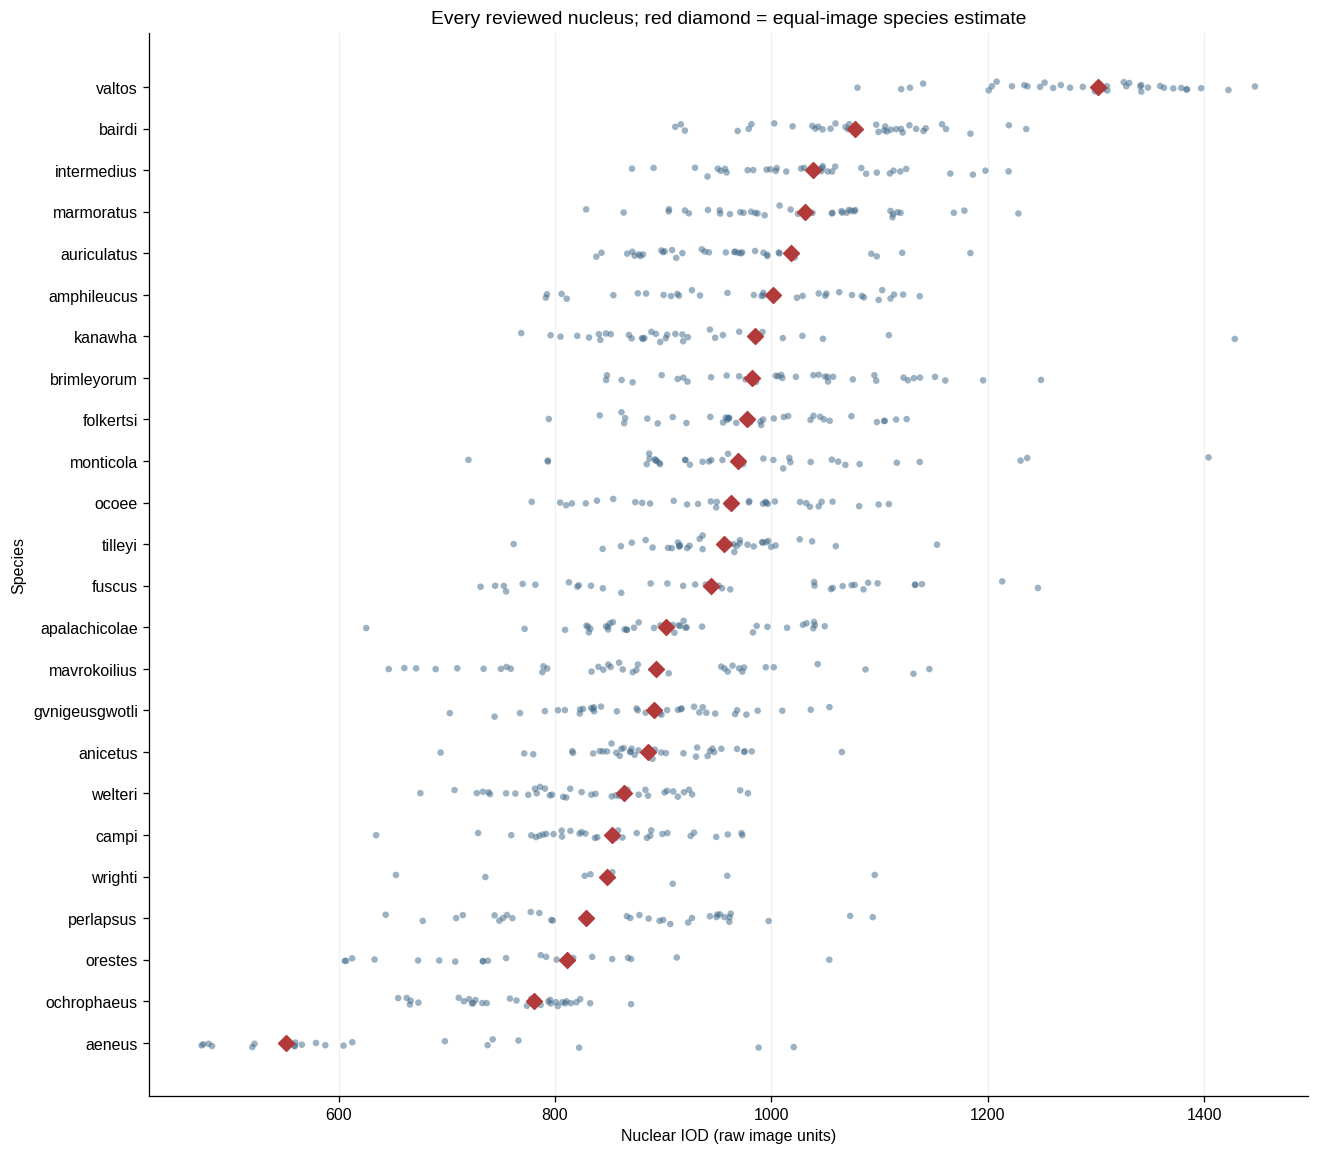

In [5]:
order = species_summary.sort_values("iod_equal_image_estimate")["species"].tolist()
rng = np.random.default_rng(20260710)
fig, ax = plt.subplots(figsize=(13, 12))
for y, species in enumerate(order):
    values = frozen.loc[frozen["species"].eq(species), "nuc_iod"].to_numpy()
    jitter = rng.normal(0, 0.065, size=len(values))
    ax.scatter(values, y + jitter, s=17, alpha=0.52, color="#426B8A", edgecolor="none")
    estimate = species_summary.loc[
        species_summary["species"].eq(species), "iod_equal_image_estimate"
    ].iloc[0]
    ax.scatter(estimate, y, marker="D", s=48, color="#B33A3A", zorder=5)
ax.set_yticks(range(len(order)), [short_species(value) for value in order])
ax.set_xlabel("Nuclear IOD (raw image units)")
ax.set_ylabel("Species")
ax.set_title("Every reviewed nucleus; red diamond = equal-image species estimate")
ax.grid(axis="x", alpha=0.18)
save_figure(fig, "01_all_raw_nuclear_iod.png")
plt.show()


## Primary genome-size estimates and conditional uncertainty

            Each estimate is calibrated as species equal-image IOD divided by
            the *D. fuscus* equal-image IOD, multiplied by **16.36 pg**.
            Confidence intervals resample images and nuclei for both the focal
            species and *D. fuscus*. They remain conditional on the observed
            images/specimens, and uncertainty in the assumed 16.36-pg reference
            value itself is not included.

            The 16.36-pg value is the existing project convention. Its exact
            original literature derivation has not been recovered; published
            *D. fuscus* values span roughly 15–18 pg in the
            [Animal Genome Size Database](https://genomesize.com/result_species.php?id=553),
            and the recent approximately 16-Gb assembly also cautions that its
            span may be slightly inflated
            ([Myers et al.](https://doi.org/10.1093/g3journal/jkaf157)).
            Therefore these are calibrated genome-size estimates, not new
            independent direct C-value measurements.


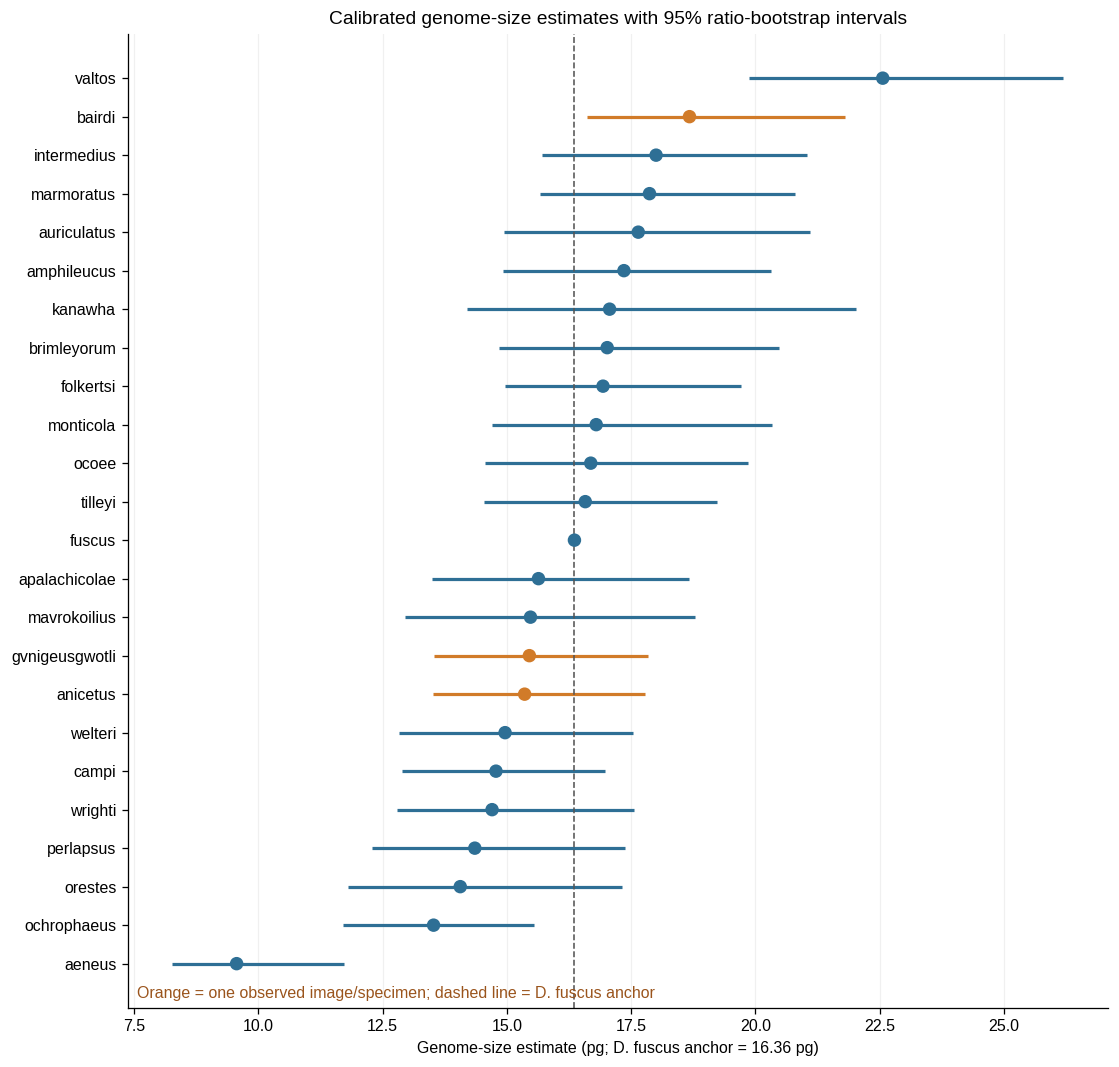

In [6]:
plot_data = species_summary.sort_values("genome_size_pg_fuscus_anchored")
y = np.arange(len(plot_data))
x = plot_data["genome_size_pg_fuscus_anchored"].to_numpy()
low = plot_data["genome_size_pg_ci_low"].to_numpy()
high = plot_data["genome_size_pg_ci_high"].to_numpy()
colors = np.where(plot_data["n_images"].eq(1), "#D17B29", "#2E6F95")
fig, ax = plt.subplots(figsize=(11, 11))
ax.hlines(y, low, high, color=colors, linewidth=2)
ax.scatter(x, y, color=colors, s=55, zorder=3)
ax.axvline(reference_pg, color="#555555", linestyle="--", linewidth=1)
ax.set_yticks(y, [short_species(value) for value in plot_data["species"]])
ax.set_xlabel("Genome-size estimate (pg; D. fuscus anchor = 16.36 pg)")
ax.set_title("Calibrated genome-size estimates with 95% ratio-bootstrap intervals")
ax.grid(axis="x", alpha=0.18)
ax.text(
    0.01,
    0.01,
    "Orange = one observed image/specimen; dashed line = D. fuscus anchor",
    transform=ax.transAxes,
    color="#9A541C",
)
save_figure(fig, "02_relative_iod_estimates.png")
plt.show()


## Measured-only time-calibrated phylogeny

            This panel includes all 24 species in the finalized literal-largest
            cell panel. Every species has observed cell and corresponding
            nucleus distributions. Fuscus-anchored genome-size estimates in pg
            are available for all 24 species, and all 24 are retained in the
            analysis. *D. aeneus*, *D. ochrophaeus*, and *D. wrighti* are
            flagged as limited-overlap quality matches so their observed sample
            sizes and uncertainty can be interpreted explicitly. Every violin is
            a bootstrap distribution of the plotted estimator, and no species
            is filled by phylogenetic imputation.


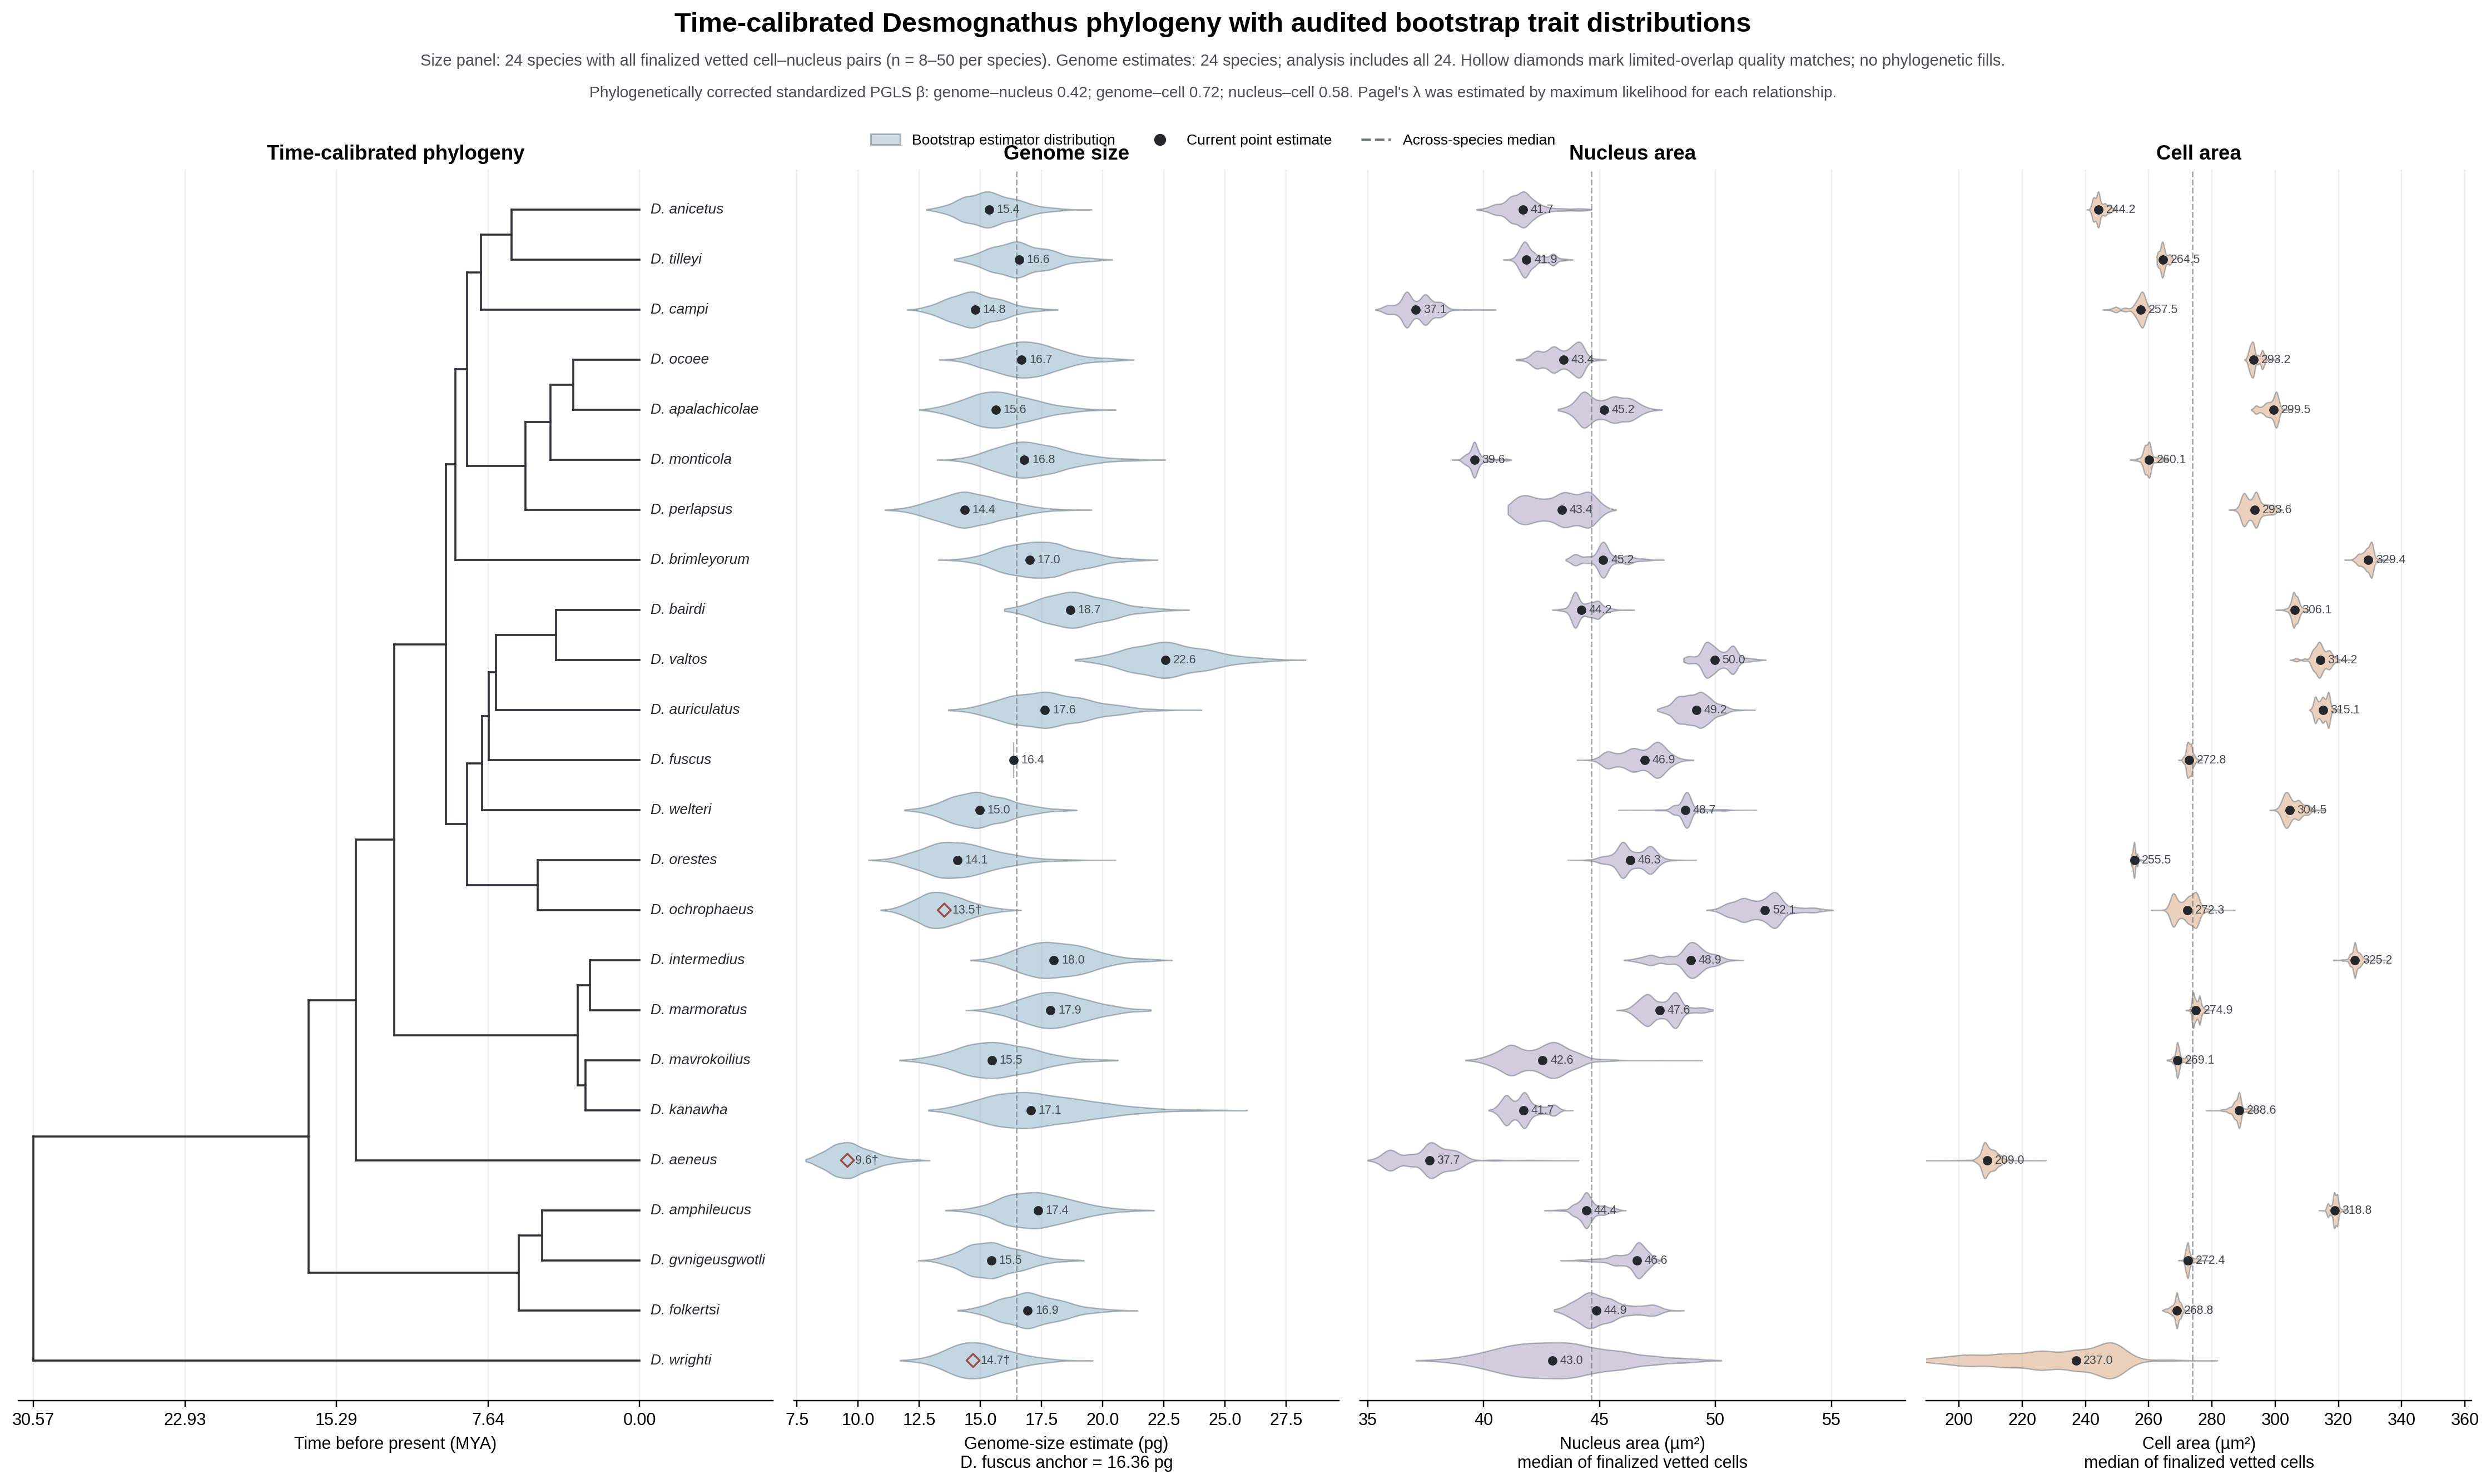

,species,genome_panel_status,include_in_primary_genome_analysis,n_genome_nuclei,n_genome_images,n_size_cells,n_size_images,size_sample_size_support,genome_size_pg_fuscus_anchored,genome_size_pg_fuscus_anchored_ci_low,genome_size_pg_fuscus_anchored_ci_high,nucleus_area_um2,nucleus_area_um2_ci_low,nucleus_area_um2_ci_high,cell_area_um2,cell_area_um2_ci_low,cell_area_um2_ci_high,tree_display_order
0,D. anicetus,finalized_included_common_support,True,39,1,50,1,top50_target_met,15.357964,13.505734,17.779700,41.6952,40.28400,43.93440,244.1952,242.19360,248.5008,1
1,D. tilleyi,finalized_included_common_support,True,36,2,50,2,top50_target_met,16.577938,14.535302,19.234726,41.8536,41.42160,43.29360,264.4776,262.75680,267.2352,2
2,D. campi,finalized_included_common_support,True,36,2,50,2,top50_target_met,14.781877,12.887861,16.973791,37.0728,35.81280,38.26170,257.4504,248.93280,259.3656,3
3,D. ocoee,finalized_included_common_support,True,35,3,50,2,top50_target_met,16.688286,14.566526,19.852253,43.4448,41.99040,44.51040,293.1552,291.44880,296.7552,4
4,D. apalachicolae,finalized_included_common_support,True,37,2,50,1,top50_target_met,15.636817,13.485365,18.666954,45.2016,43.71840,46.82880,299.5488,293.65920,301.4064,5
5,D. monticola,finalized_included_common_support,True,36,2,50,2,top50_target_met,16.798206,14.693459,20.337420,39.6072,39.12480,40.96800,260.0784,256.52160,264.5712,6
6,D. perlapsus,finalized_included_common_support,True,33,3,50,1,top50_target_met,14.356038,12.278422,17.374859,43.3800,41.29920,45.00000,293.5512,289.32480,299.8656,7
7,D. brimleyorum,finalized_included_common_support,True,35,2,50,2,top50_target_met,17.018945,14.840062,20.474376,45.1656,43.89120,46.84428,329.4000,325.26720,332.1243,8
8,D. bairdi,finalized_included_common_support,True,37,1,50,1,top50_target_met,18.674446,16.617314,21.809041,44.2080,43.55280,45.43200,306.1368,303.52320,309.7152,9
9,D. valtos,finalized_included_common_support,True,37,2,50,2,top50_target_met,22.561835,19.879090,26.195025,49.9680,48.79440,51.43680,314.1936,307.03680,319.1688,10


,comparison,left_metric,right_metric,spearman_rho,p_value_descriptive_only,pearson_r,pearson_p_value_descriptive_only,n_species,phylogenetically_corrected,pgls_model,trait_transformation,pgls_standardized_beta,pgls_standard_error,pgls_ci_low,pgls_ci_high,pgls_t_value,pgls_degrees_freedom,pgls_p_value,pagel_lambda,pagel_lambda_at_lower_boundary,pgls_generalized_r_squared,pgls_intercept_z,pgls_var_intercept,pgls_cov_intercept_slope,pgls_var_slope,predictor_log10_mean,predictor_log10_sd,outcome_log10_mean,outcome_log10_sd
0,genome_size_vs_nucleus_area,genome_size_pg_fuscus_anchored,nucleus_area_um2,0.294783,0.162011,0.399108,0.053359,24,True,Pagel_lambda_ML,log10_then_sample_zscore,0.419018,0.193581,0.017555,0.820482,2.164558,22,0.041544,1.000000e-07,True,0.175576,-0.000000e+00,0.035912,0.0,0.037474,1.203306,0.066856,1.648573,0.037204
1,genome_size_vs_cell_area,genome_size_pg_fuscus_anchored,cell_area_um2,0.669565,0.000346,0.678226,0.000270,24,True,Pagel_lambda_ML,log10_then_sample_zscore,0.716664,0.148690,0.408300,1.025029,4.819855,22,0.000082,1.000000e-07,True,0.513608,-6.000000e-08,0.021188,0.0,0.022109,1.203306,0.066856,2.446379,0.047889
2,nucleus_area_vs_cell_area,nucleus_area_um2,cell_area_um2,0.573043,0.003423,0.557009,0.004694,24,True,Pagel_lambda_ML,log10_then_sample_zscore,0.579301,0.173783,0.218898,0.939705,3.333479,22,0.003013,1.000000e-07,True,0.335590,-8.000000e-08,0.028942,0.0,0.030200,1.648573,0.037204,2.446379,0.047889


In [7]:
phylogeny_figure = FIGURE_DIR / "07_measured_phylogeny_genome_nucleus_cell.png"
phylogeny_summary_path = REPORT_DIR / "phylogeny_genome_nucleus_cell_summary.csv"
phylogeny_correlation_path = REPORT_DIR / "phylogeny_genome_nucleus_cell_correlations.csv"
assert phylogeny_figure.exists(), "Run the measured phylogeny figure builder first"
assert phylogeny_summary_path.exists()
assert phylogeny_correlation_path.exists()
display(Image(filename=str(phylogeny_figure)))
display(pd.read_csv(phylogeny_summary_path))
display(pd.read_csv(phylogeny_correlation_path))


## Pairwise genome-size, nucleus, and cell relationships

            These three panels show every unique pair of traits. Points are
            species estimates and bars are their bootstrap intervals. Positive
            relationships are biologically consistent with the classical
            nucleotypic expectation, but they are descriptive rather than
            causal: the calibrated genome estimate is derived from IOD, which
            contains nuclear area algebraically; the size panel is an upper-tail
            estimand with observed reviewed counts; and the fitted associations
            use Pagel-λ PGLS on the time-calibrated phylogeny.


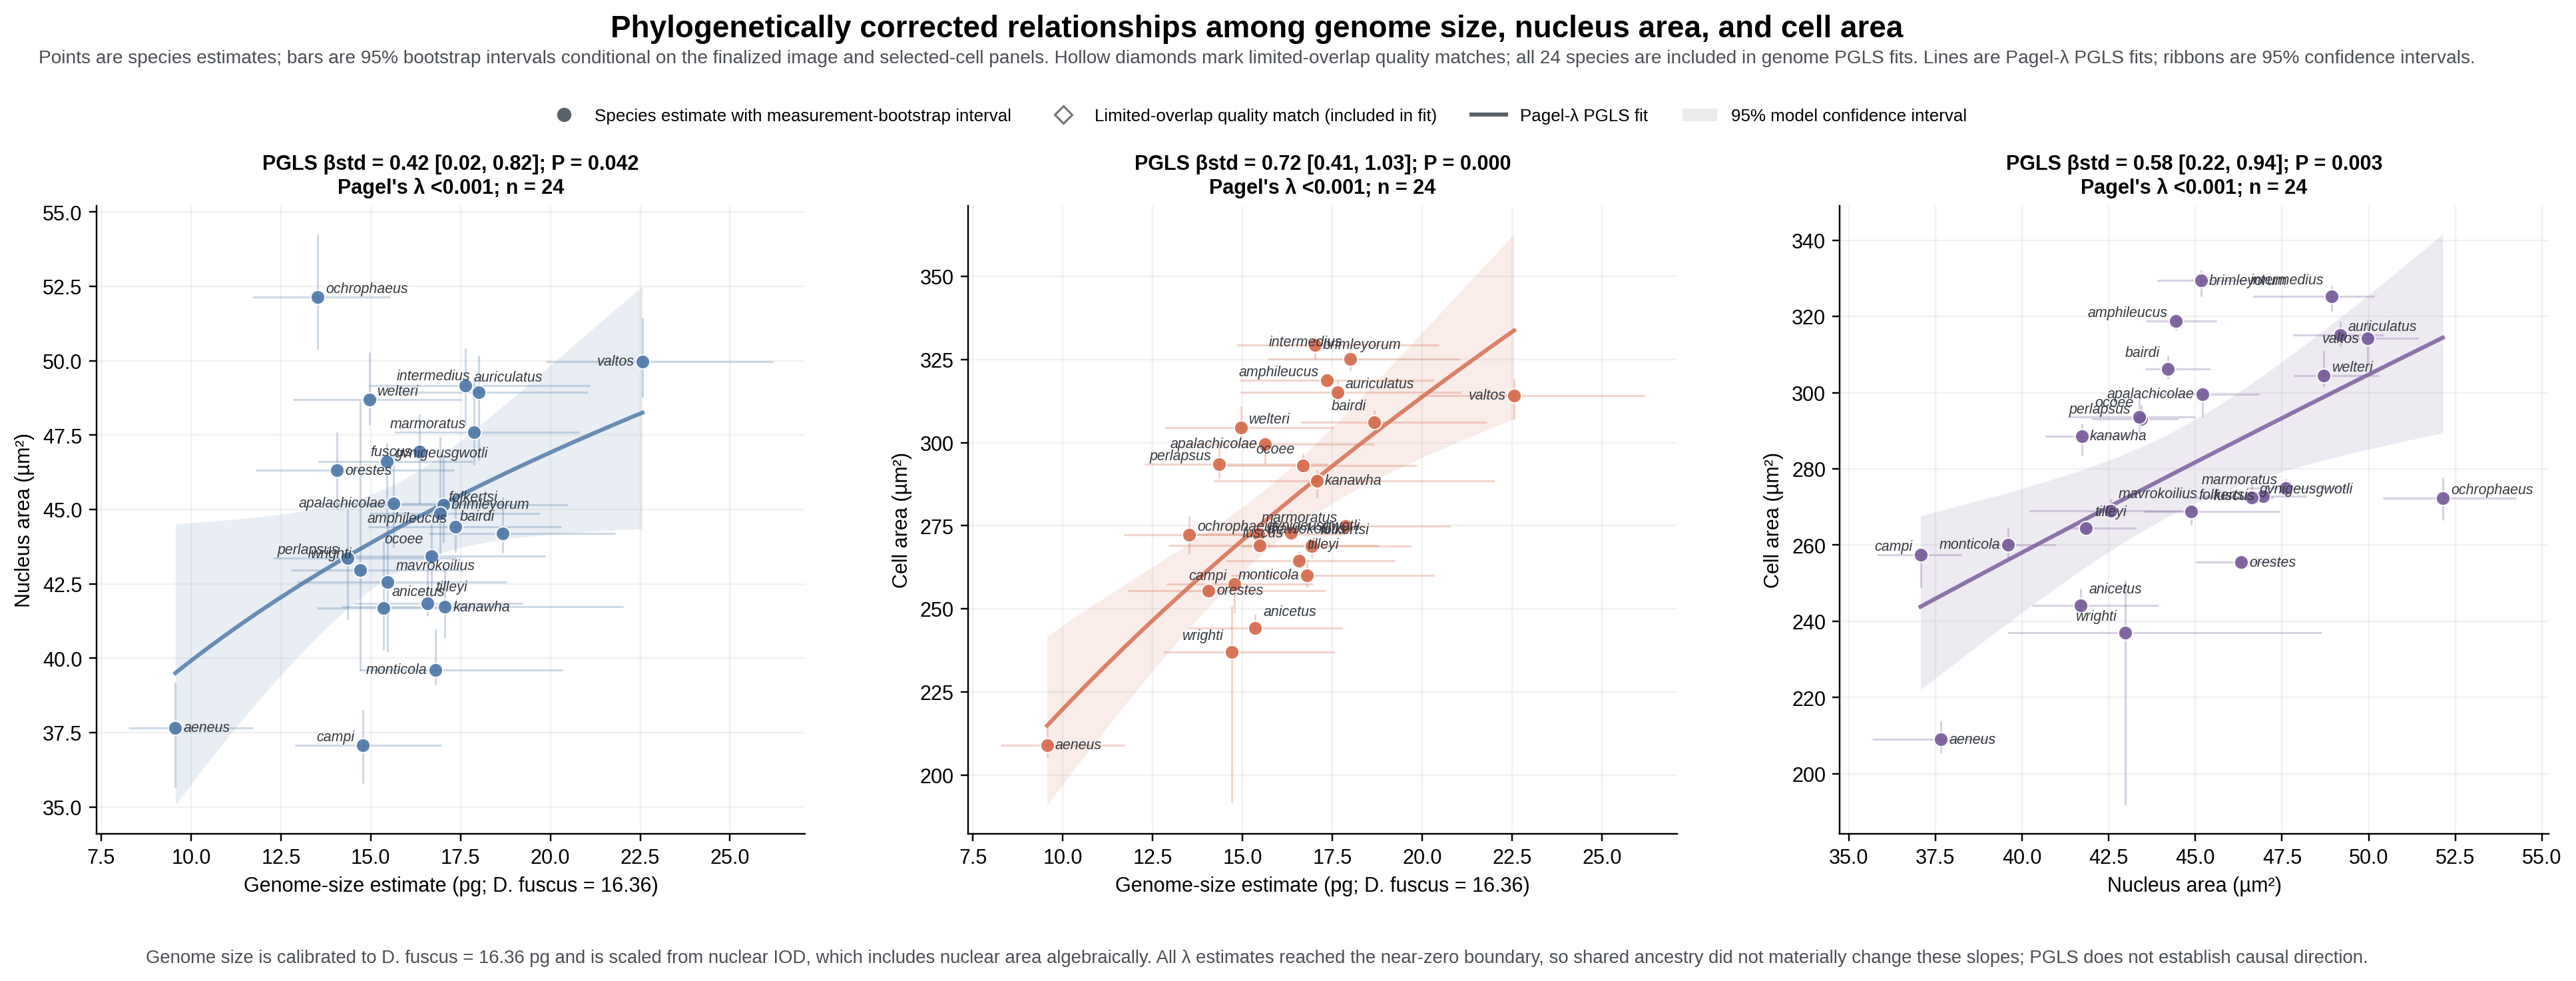

,comparison,left_metric,right_metric,spearman_rho,p_value_descriptive_only,pearson_r,pearson_p_value_descriptive_only,n_species,phylogenetically_corrected,pgls_model,trait_transformation,pgls_standardized_beta,pgls_standard_error,pgls_ci_low,pgls_ci_high,pgls_t_value,pgls_degrees_freedom,pgls_p_value,pagel_lambda,pagel_lambda_at_lower_boundary,pgls_generalized_r_squared,pgls_intercept_z,pgls_var_intercept,pgls_cov_intercept_slope,pgls_var_slope,predictor_log10_mean,predictor_log10_sd,outcome_log10_mean,outcome_log10_sd
0,genome_size_vs_nucleus_area,genome_size_pg_fuscus_anchored,nucleus_area_um2,0.294783,0.162011,0.399108,0.053359,24,True,Pagel_lambda_ML,log10_then_sample_zscore,0.419018,0.193581,0.017555,0.820482,2.164558,22,0.041544,1.000000e-07,True,0.175576,-0.000000e+00,0.035912,0.0,0.037474,1.203306,0.066856,1.648573,0.037204
1,genome_size_vs_cell_area,genome_size_pg_fuscus_anchored,cell_area_um2,0.669565,0.000346,0.678226,0.000270,24,True,Pagel_lambda_ML,log10_then_sample_zscore,0.716664,0.148690,0.408300,1.025029,4.819855,22,0.000082,1.000000e-07,True,0.513608,-6.000000e-08,0.021188,0.0,0.022109,1.203306,0.066856,2.446379,0.047889
2,nucleus_area_vs_cell_area,nucleus_area_um2,cell_area_um2,0.573043,0.003423,0.557009,0.004694,24,True,Pagel_lambda_ML,log10_then_sample_zscore,0.579301,0.173783,0.218898,0.939705,3.333479,22,0.003013,1.000000e-07,True,0.335590,-8.000000e-08,0.028942,0.0,0.030200,1.648573,0.037204,2.446379,0.047889


In [8]:
pairwise_figure = FIGURE_DIR / "08_pairwise_genome_nucleus_cell_relationships.png"
assert pairwise_figure.exists(), "Run the measured phylogeny figure builder first"
display(Image(filename=str(pairwise_figure)))
display(pd.read_csv(phylogeny_correlation_path))


## Image-to-image variation within species


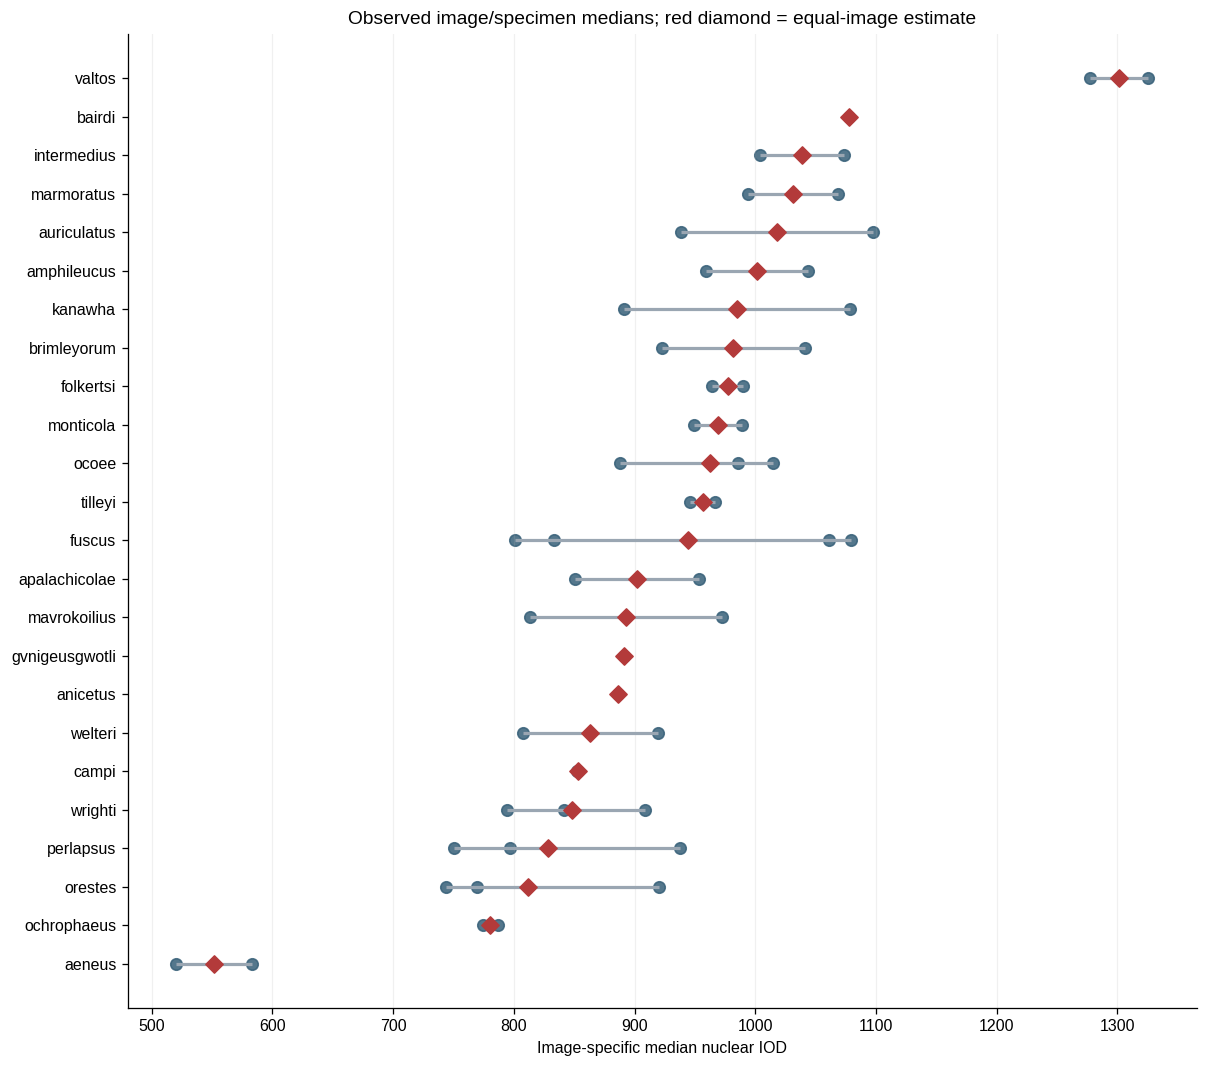

,species,filename,specimen_group,n_nuclei,image_median_iod,image_mean_iod,image_median_nucleus_area_um2,image_median_mean_od,image_median_match_log_edge_sharpness,image_median_match_log_relative_ring_noise
0,D. aeneus,Process_393_green.ome.tiff,168277,1,520.236843,520.236843,31.1184,0.240739,0.130560,0.087969
1,D. aeneus,Process_395_green.ome.tiff,168277,20,583.440599,641.916506,38.0664,0.225259,0.123364,0.070175
2,D. amphileucus,Process_337_raw_green.ome.tiff,3442,16,958.910100,954.290142,41.8464,0.325934,0.110751,0.104804
3,D. amphileucus,Process_338_raw_green.ome.tiff,3437,17,1043.757034,1008.816285,42.3504,0.343207,0.109622,0.106543
4,D. anicetus,Process_343_raw_green.ome.tiff,3441,39,886.076743,887.791193,40.1904,0.316773,0.109817,0.106610
5,D. apalachicolae,Process_356_raw_green.ome.tiff,3471,18,953.559841,957.068988,44.7840,0.310104,0.108604,0.100363
6,D. apalachicolae,Process_357_raw_green.ome.tiff,3472,19,850.770405,855.021525,38.2320,0.321398,0.112857,0.121027
7,D. auriculatus,Process_324_raw_green.ome.tiff,3462,5,1097.454415,1092.110361,45.9216,0.329243,0.107846,0.100379
8,D. auriculatus,Process_331_raw_green.ome.tiff,3463,31,938.497898,937.652216,48.1536,0.283869,0.109539,0.105361
9,D. bairdi,Process_359_raw_green.ome.tiff,3455,37,1077.420946,1076.447484,46.3536,0.341027,0.109854,0.102191


In [9]:
species_order = species_summary.sort_values("iod_equal_image_estimate")["species"].tolist()
fig, ax = plt.subplots(figsize=(12, 11))
for y, species in enumerate(species_order):
    image_values = image_summary.loc[
        image_summary["species"].eq(species), "image_median_iod"
    ].to_numpy()
    estimate = species_summary.loc[
        species_summary["species"].eq(species), "iod_equal_image_estimate"
    ].iloc[0]
    if len(image_values) > 1:
        ax.hlines(y, image_values.min(), image_values.max(), color="#9AA6B2", linewidth=2)
    ax.scatter(image_values, np.full(len(image_values), y), s=52, color="#365F78", alpha=0.85)
    ax.scatter(estimate, y, s=58, marker="D", color="#B33A3A", zorder=4)
ax.set_yticks(range(len(species_order)), [short_species(value) for value in species_order])
ax.set_xlabel("Image-specific median nuclear IOD")
ax.set_title("Observed image/specimen medians; red diamond = equal-image estimate")
ax.grid(axis="x", alpha=0.18)
save_figure(fig, "03_image_level_iod.png")
plt.show()
display(image_summary.sort_values(["species", "filename"]))


## What makes up IOD?

            Nuclear IOD is algebraically the nuclear mask area in pixels
            multiplied by mean optical density. Its association with nuclear
            area therefore cannot independently validate a biological
            genome-size mechanism. Both components are shown explicitly.


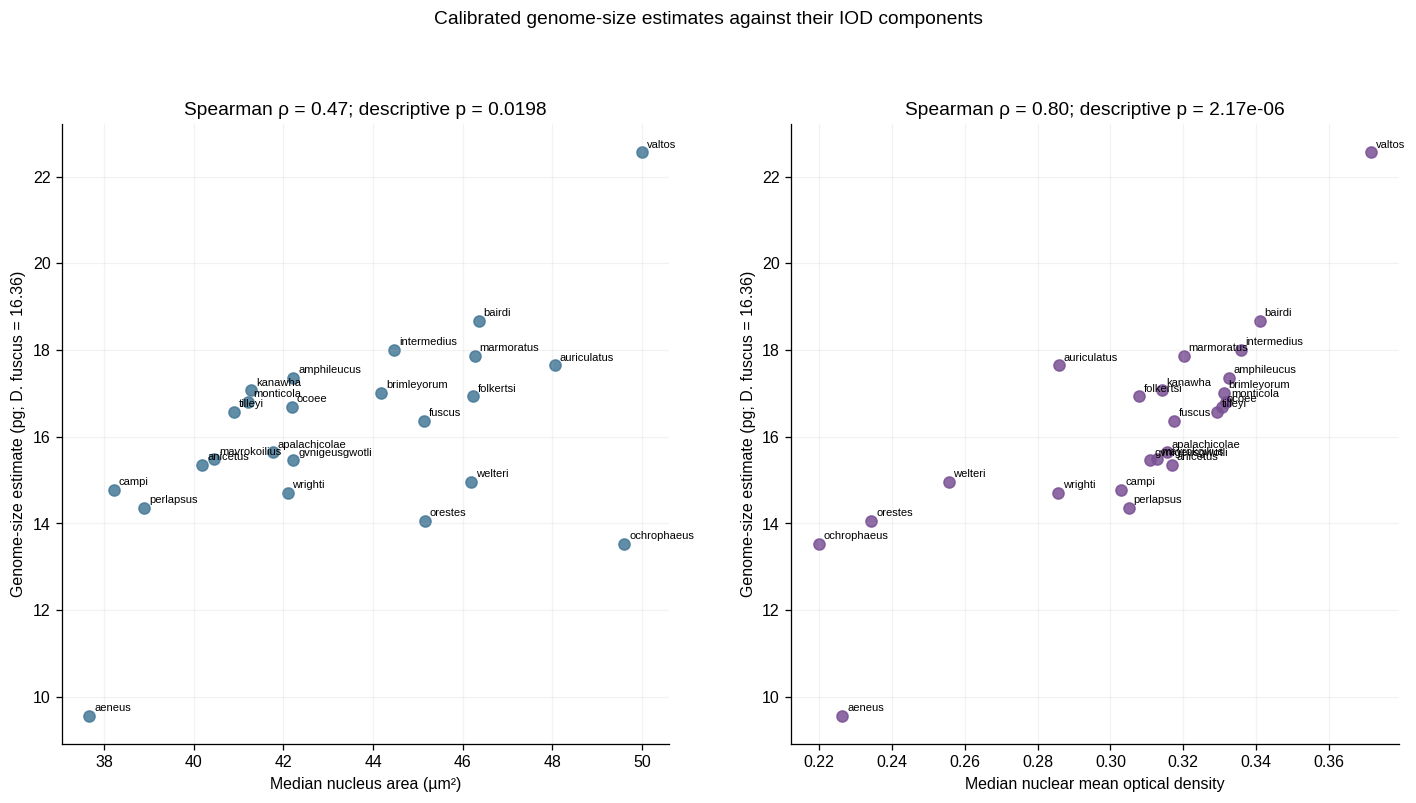

IOD vs median nucleus area: rho=0.472, p=0.01979
IOD vs median mean OD: rho=0.804, p=2.172e-06


In [10]:
component_data = species_summary.copy()
rho_area, p_area = spearmanr(
    component_data["median_nucleus_area_um2"],
    component_data["genome_size_pg_fuscus_anchored"],
)
rho_od, p_od = spearmanr(
    component_data["median_nucleus_mean_od"],
    component_data["genome_size_pg_fuscus_anchored"],
)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
specs = [
    (
        "median_nucleus_area_um2",
        "Median nucleus area (µm²)",
        rho_area,
        p_area,
        "#477998",
    ),
    (
        "median_nucleus_mean_od",
        "Median nuclear mean optical density",
        rho_od,
        p_od,
        "#7A5195",
    ),
]
for ax, (column, xlabel, rho, p_value, color) in zip(axes, specs):
    ax.scatter(
        component_data[column],
        component_data["genome_size_pg_fuscus_anchored"],
        s=48,
        color=color,
        alpha=0.85,
    )
    for row in component_data.itertuples():
        ax.annotate(
            short_species(row.species),
            (getattr(row, column), row.genome_size_pg_fuscus_anchored),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Genome-size estimate (pg; D. fuscus = 16.36)")
    ax.set_title(f"Spearman ρ = {rho:.2f}; descriptive p = {p_value:.3g}")
    ax.grid(alpha=0.16)
fig.suptitle("Calibrated genome-size estimates against their IOD components", y=1.02)
save_figure(fig, "04_iod_components.png")
plt.show()
print(f"IOD vs median nucleus area: rho={rho_area:.3f}, p={p_area:.4g}")
print(f"IOD vs median mean OD: rho={rho_od:.3f}, p={p_od:.4g}")


## Aggregation-method sensitivity


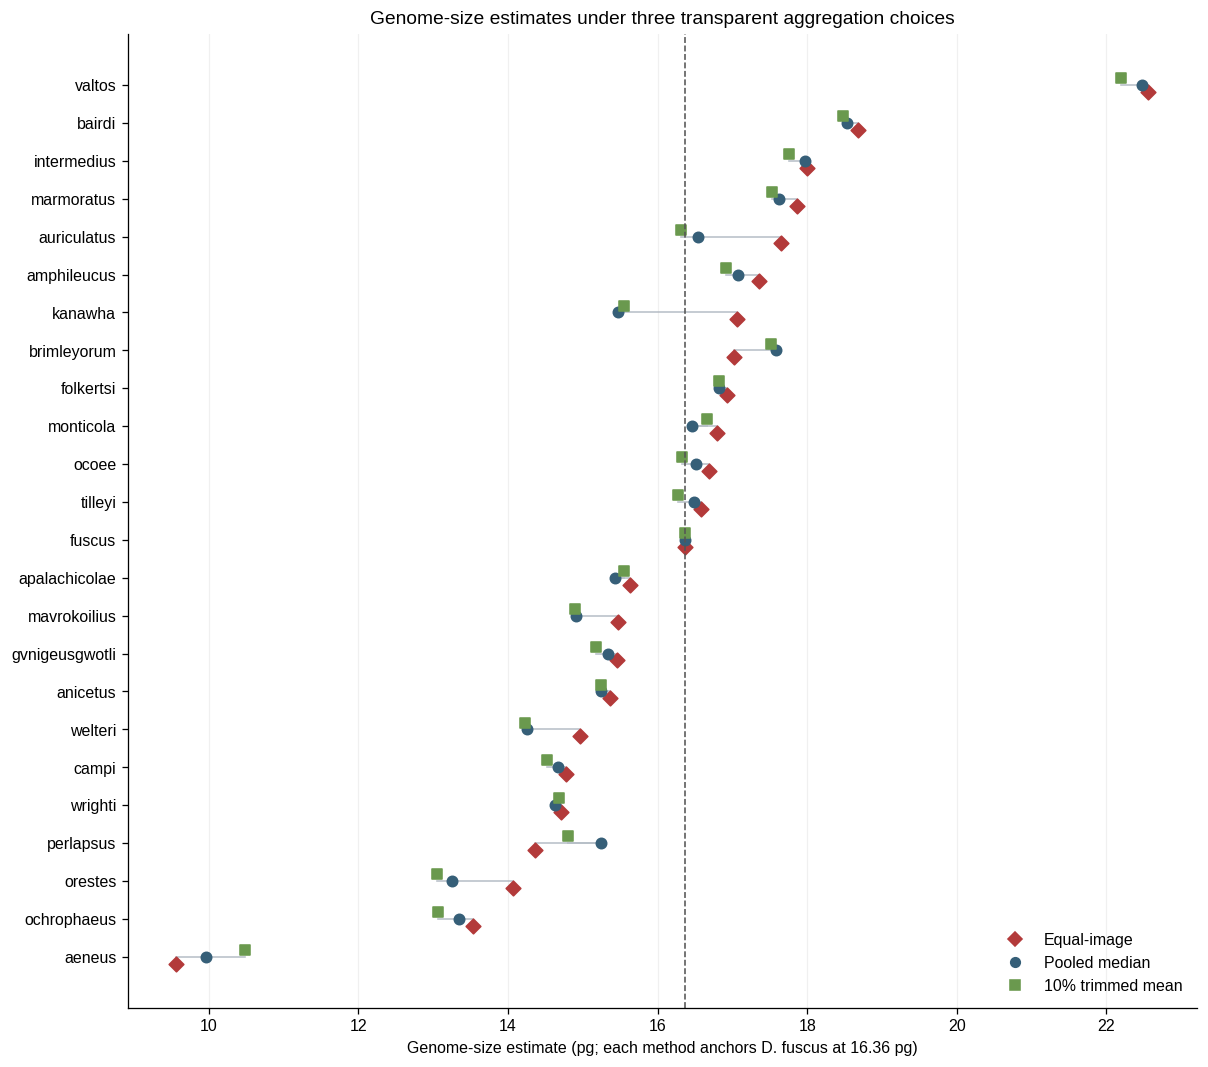

,species,pooled_median_difference_pct,trimmed_mean_difference_pct,max_abs_shift_pct
23,D. aeneus,4.948016,10.873622,10.873622
6,D. kanawha,-8.620750,-7.845138,8.620750
20,D. perlapsus,7.040114,4.296301,7.040114
4,D. auriculatus,-5.511722,-6.423968,6.423968
21,D. orestes,-4.996846,-6.109445,6.109445
7,D. brimleyorum,4.150937,4.097254,4.150937
17,D. welteri,-3.969918,-3.789938,3.969918
14,D. mavrokoilius,-2.869340,-2.648066,2.869340
22,D. ochrophaeus,-0.553110,-2.286931,2.286931
5,D. amphileucus,-0.872148,-1.405629,1.405629


In [11]:
sensitivity = species_summary[[
    "species",
    "iod_equal_image_estimate",
    "iod_pooled_nucleus_median",
    "iod_trimmed_mean_10pct",
]].copy()
method_columns = [
    "iod_equal_image_estimate",
    "iod_pooled_nucleus_median",
    "iod_trimmed_mean_10pct",
]
method_labels = ["Equal-image", "Pooled median", "10% trimmed mean"]
for column in method_columns:
    method_reference_iod = sensitivity.loc[
        sensitivity["species"].eq(analysis.REFERENCE_SPECIES), column
    ].iloc[0]
    sensitivity[column + "_pg"] = (
        sensitivity[column] / method_reference_iod * reference_pg
    )
order = species_summary.sort_values("genome_size_pg_fuscus_anchored")["species"].tolist()
fig, ax = plt.subplots(figsize=(12, 11))
offsets = [-0.18, 0.0, 0.18]
markers = ["D", "o", "s"]
colors = ["#B33A3A", "#365F78", "#6A994E"]
for y, species in enumerate(order):
    row = sensitivity.loc[sensitivity["species"].eq(species)].iloc[0]
    values = [row[column + "_pg"] for column in method_columns]
    ax.plot(values, [y] * 3, color="#B8C0C8", linewidth=1, zorder=1)
    for offset, value, marker, color in zip(offsets, values, markers, colors):
        ax.scatter(value, y + offset, marker=marker, s=42, color=color, zorder=2)
ax.axvline(reference_pg, color="#555555", linestyle="--", linewidth=1)
ax.set_yticks(range(len(order)), [short_species(value) for value in order])
ax.set_xlabel("Genome-size estimate (pg; each method anchors D. fuscus at 16.36 pg)")
ax.set_title("Genome-size estimates under three transparent aggregation choices")
handles = [
    plt.Line2D([], [], marker=marker, linestyle="", color=color, label=label)
    for marker, color, label in zip(markers, colors, method_labels)
]
ax.legend(handles=handles, frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.18)
save_figure(fig, "05_aggregation_sensitivity.png")
plt.show()
display(
    species_summary[[
        "species",
        "pooled_median_difference_pct",
        "trimmed_mean_difference_pct",
    ]]
    .assign(max_abs_shift_pct=lambda x: x[[
        "pooled_median_difference_pct", "trimmed_mean_difference_pct"
    ]].abs().max(axis=1))
    .sort_values("max_abs_shift_pct", ascending=False)
)


## Technical-quality balance and residual IOD associations


,species,template_species,n_nuclei,standardized_mean_difference_match_log_edge_sharpness,ks_distance_match_log_edge_sharpness,standardized_mean_difference_match_log_relative_ring_noise,ks_distance_match_log_relative_ring_noise,max_abs_standardized_mean_difference,max_ks_distance,passes_prespecified_balance_thresholds
0,D. aeneus,D. apalachicolae,21,0.865360,0.606178,-0.669481,0.647362,0.865360,0.647362,False
1,D. amphileucus,D. apalachicolae,33,0.049932,0.147420,0.007598,0.099099,0.049932,0.147420,True
2,D. anicetus,D. apalachicolae,39,0.004167,0.092862,-0.015578,0.127512,0.015578,0.127512,True
3,D. apalachicolae,D. apalachicolae,37,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
4,D. auriculatus,D. apalachicolae,36,-0.043963,0.120120,-0.004040,0.103604,0.043963,0.120120,True
5,D. bairdi,D. apalachicolae,37,-0.004509,0.108108,-0.010801,0.108108,0.010801,0.108108,True
6,D. brimleyorum,D. apalachicolae,35,0.001098,0.104247,-0.005874,0.070270,0.005874,0.104247,True
7,D. campi,D. apalachicolae,36,0.022809,0.123123,-0.007474,0.103604,0.022809,0.123123,True
8,D. folkertsi,D. apalachicolae,37,-0.003637,0.162162,0.004221,0.108108,0.004221,0.162162,True
9,D. fuscus,D. apalachicolae,35,0.009899,0.110425,-0.014766,0.098842,0.014766,0.110425,True


,quality_feature,within_species_centered_spearman_rho,p_value_descriptive_only,n_nuclei
0,match_log_edge_sharpness,-0.088408,0.012095,805
1,match_log_relative_ring_noise,0.052963,0.133247,805


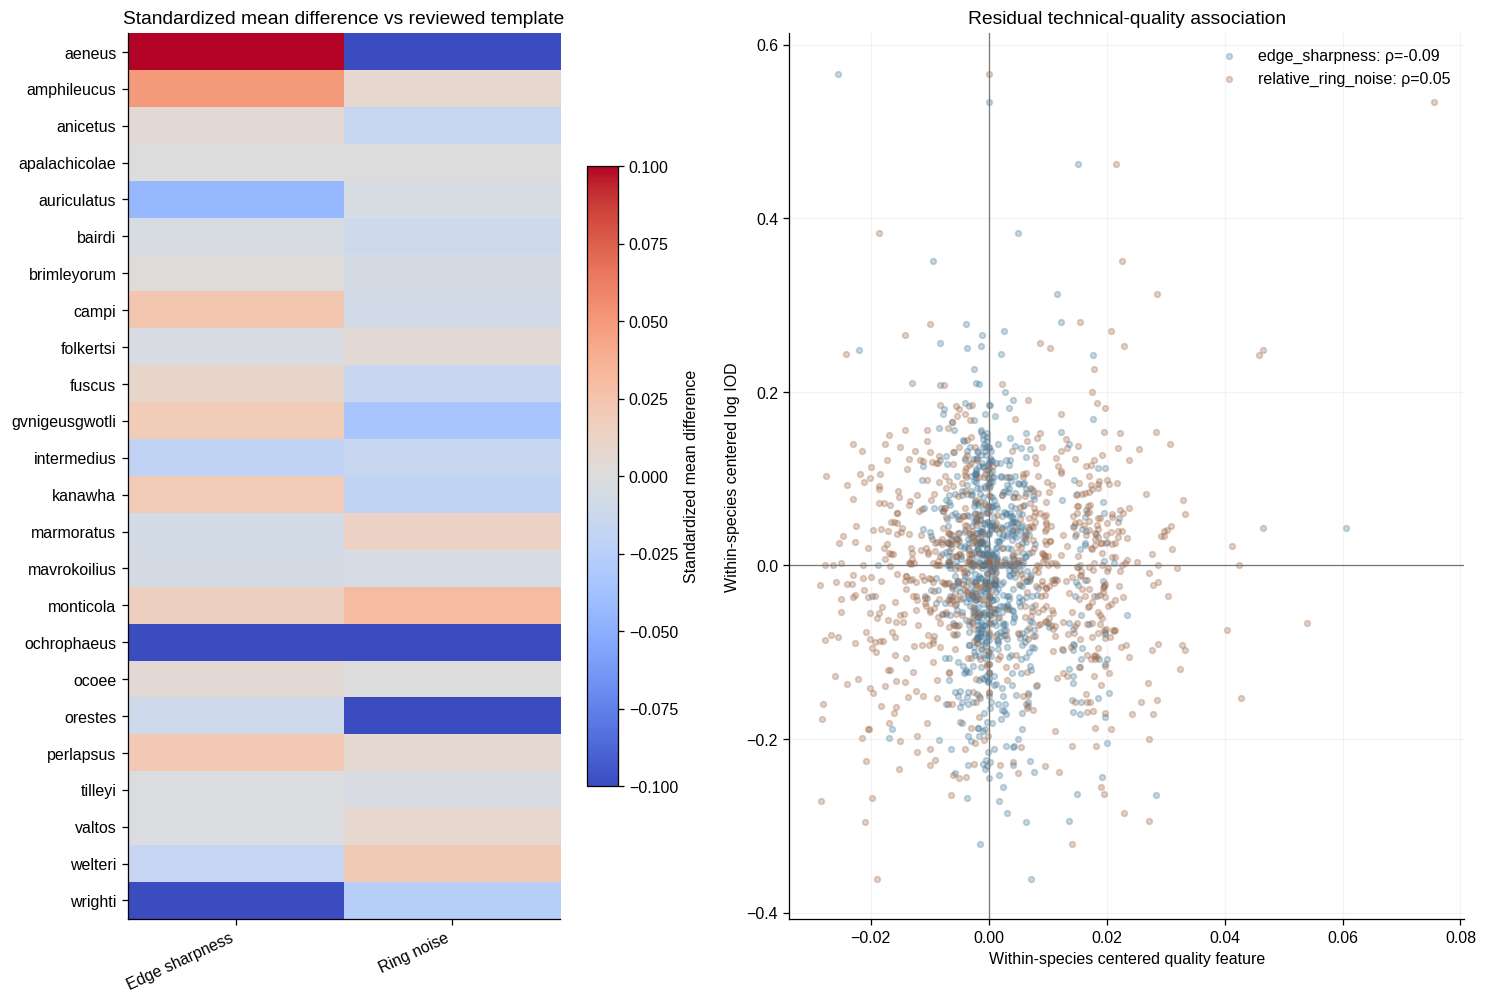

Worst absolute standardized mean difference: 0.865
Worst KS distance: 0.647


In [12]:
display(quality_balance)
display(quality_residual)

balance_plot = quality_balance.sort_values("species")
mean_columns = [
    "standardized_mean_difference_match_log_edge_sharpness",
    "standardized_mean_difference_match_log_relative_ring_noise",
]
matrix = balance_plot[mean_columns].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(15, 10), gridspec_kw={"width_ratios": [1.0, 1.25]})
image = axes[0].imshow(matrix, cmap="coolwarm", vmin=-0.10, vmax=0.10, aspect="auto")
axes[0].set_yticks(range(len(balance_plot)), [short_species(v) for v in balance_plot["species"]])
axes[0].set_xticks([0, 1], ["Edge sharpness", "Ring noise"], rotation=25, ha="right")
axes[0].set_title("Standardized mean difference vs reviewed template")
fig.colorbar(image, ax=axes[0], shrink=0.7, label="Standardized mean difference")

centered_log_iod = np.log(frozen["nuc_iod"]) - np.log(frozen["nuc_iod"]).groupby(
    frozen["species"]
).transform("median")
feature_colors = ["#477998", "#9C6644"]
for feature, color in zip(analysis.MATCH_FEATURES, feature_colors):
    centered_quality = frozen[feature] - frozen[feature].groupby(
        frozen["species"]
    ).transform("median")
    rho = quality_residual.loc[
        quality_residual["quality_feature"].eq(feature),
        "within_species_centered_spearman_rho",
    ].iloc[0]
    axes[1].scatter(
        centered_quality,
        centered_log_iod,
        s=13,
        alpha=0.30,
        color=color,
        label=f"{feature.replace('match_log_', '')}: ρ={rho:.2f}",
    )
axes[1].axhline(0, color="#777777", linewidth=0.8)
axes[1].axvline(0, color="#777777", linewidth=0.8)
axes[1].set_xlabel("Within-species centered quality feature")
axes[1].set_ylabel("Within-species centered log IOD")
axes[1].set_title("Residual technical-quality association")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)
save_figure(fig, "06_quality_diagnostics.png")
plt.show()
print(
    "Worst absolute standardized mean difference:",
    round(quality_balance["max_abs_standardized_mean_difference"].max(), 3),
)
print(
    "Worst KS distance:",
    round(quality_balance["max_ks_distance"].max(), 3),
)


## Direct reading of the current results


In [13]:
top = species_summary.iloc[0]
bottom = species_summary.iloc[-1]
fold = top["iod_equal_image_estimate"] / bottom["iod_equal_image_estimate"]
single_image = species_summary.loc[
    species_summary["n_images"].eq(1), "species"
].tolist()
median_genome_estimate = species_summary["genome_size_pg_fuscus_anchored"].median()
intervals_crossing_median = int((
    species_summary["genome_size_pg_ci_low"].le(median_genome_estimate)
    & species_summary["genome_size_pg_ci_high"].ge(median_genome_estimate)
).sum())
method_shift = species_summary.assign(
    max_shift=lambda x: x[[
        "pooled_median_difference_pct", "trimmed_mean_difference_pct"
    ]].abs().max(axis=1)
).sort_values("max_shift", ascending=False).iloc[0]
rho_area, p_area = spearmanr(
    species_summary["median_nucleus_area_um2"],
    species_summary["genome_size_pg_fuscus_anchored"],
)
rho_od, p_od = spearmanr(
    species_summary["median_nucleus_mean_od"],
    species_summary["genome_size_pg_fuscus_anchored"],
)

display(HTML(f"""
<div style="border-left:5px solid #365F78;background:#f4f7f9;padding:14px 18px">
<p><b>Largest genome-size estimate:</b> {top['species']}
({top['genome_size_pg_fuscus_anchored']:.2f} pg;
95% interval {top['genome_size_pg_ci_low']:.2f}–{top['genome_size_pg_ci_high']:.2f}).</p>
<p><b>Smallest genome-size estimate:</b> {bottom['species']}
({bottom['genome_size_pg_fuscus_anchored']:.2f} pg;
95% interval {bottom['genome_size_pg_ci_low']:.2f}–{bottom['genome_size_pg_ci_high']:.2f}).</p>
<p><b>Observed range:</b> {fold:.2f}-fold from highest to lowest.</p>
<p><b>Rank resolution:</b> {intervals_crossing_median} of {len(species_summary)}
intervals cross the across-species median ({median_genome_estimate:.2f} pg), so exact middle ranks should not be treated as
sharply separated.</p>
<p><b>Aggregation sensitivity:</b> the largest shift from equal-image weighting is
{method_shift['max_shift']:.1f}% for {method_shift['species']}.</p>
<p><b>Measurement components:</b> calibrated genome size correlates with median nucleus area
(ρ={rho_area:.2f}) and median mean optical density (ρ={rho_od:.2f}). This is expected
because both are algebraic components of IOD.</p>
<p><b>Calibration boundary:</b> all pg estimates are conditional on the project convention
{analysis.REFERENCE_SPECIES} = {analysis.REFERENCE_GENOME_SIZE_PG:.2f} pg; a revised anchor would rescale every estimate proportionally.</p>
<p><b>Single-image limitation:</b> {', '.join(single_image)} have only one observed
image/specimen, so their interval cannot measure between-image variation.</p>
</div>
"""))


## Conclusions and next validation step

            1. The finalized panel provides **fuscus-anchored genome-size estimates
               in pg** for all 24 measured species, and all 24 are included in
               the genome comparisons.
            2. Equal-image weighting is the primary estimate because it avoids
               letting images with more accepted nuclei dominate.
            3. The raw values, image-specific medians, bootstrap intervals,
               alternative aggregations, and technical-quality diagnostics
               remain visible rather than collapsing the evidence to one
               number per species.
            4. Most middle-ranked species have overlapping intervals. The point
               ranking is descriptive, not evidence that every adjacent pair
               differs biologically.
            5. The pg scale is conditional on *D. fuscus* = 16.36 pg. Treating
               these estimates as independent direct C-values would require a
               DNA-content standard processed with the same staining and
               imaging protocol; changing the assumed reference value rescales
               every species proportionally.
            6. *D. aeneus*, *D. ochrophaeus*, and *D. wrighti* retain limited-overlap
               quality flags and their observed nucleus counts are reported, but
               they are included in the analysis with the other 21 species.


## Reproducibility and exported files


In [14]:
exports = pd.DataFrame([
    {"artifact": "Genome-size analysis source", "path": "path_analysis/scripts/build_frozen_genome_iod_notebook.py"},
    {"artifact": "Tree/pairwise figure source", "path": "path_analysis/scripts/build_frozen_genome_iod_phylogeny_figure.py"},
    {"artifact": "Finalized 805-nucleus source", "path": str(analysis.FROZEN_PATH)},
    {"artifact": "Species result table", "path": str(analysis.SPECIES_SUMMARY_PATH)},
    {"artifact": "Image result table", "path": str(analysis.IMAGE_SUMMARY_PATH)},
    {"artifact": "Frozen quality balance", "path": str(analysis.QUALITY_BALANCE_PATH)},
    {"artifact": "Residual quality diagnostics", "path": str(analysis.QUALITY_RESIDUAL_PATH)},
    {"artifact": "Measured phylogeny figure", "path": str(analysis.FIGURE_DIR / "07_measured_phylogeny_genome_nucleus_cell.png")},
    {"artifact": "Pairwise trait figure", "path": str(analysis.FIGURE_DIR / "08_pairwise_genome_nucleus_cell_relationships.png")},
    {"artifact": "Measured phylogeny source table", "path": str(analysis.REPORT_DIR / "phylogeny_genome_nucleus_cell_summary.csv")},
    {"artifact": "Measured phylogeny correlation table", "path": str(analysis.REPORT_DIR / "phylogeny_genome_nucleus_cell_correlations.csv")},
    {"artifact": "Analysis manifest", "path": str(analysis.ANALYSIS_MANIFEST_PATH)},
    {"artifact": "Canonical executed notebook", "path": str(analysis.NOTEBOOK_PATH)},
])
display(exports)
print("Rebuild all eight lightweight notebook sources and genome-size artifacts:")
print("  scripts/run_in_dusky.sh python scripts/processing/build_research_review_notebooks.py")
print("Execute this canonical notebook in place:")
print(
    "  scripts/run_in_dusky.sh jupyter nbconvert --to notebook --execute "
    "notebooks/research_review/06_genome_size_estimation.ipynb --inplace "
    "--ExecutePreprocessor.timeout=600"
)


,artifact,path
0,Genome-size analysis source,path_analysis/scripts/build_frozen_genome_iod_...
1,Tree/pairwise figure source,path_analysis/scripts/build_frozen_genome_iod_...
2,Finalized 805-nucleus source,/home/jake/Projects/Desmognathus_TE/path_analy...
3,Species result table,/home/jake/Projects/Desmognathus_TE/results/da...
4,Image result table,/home/jake/Projects/Desmognathus_TE/results/da...
5,Frozen quality balance,/home/jake/Projects/Desmognathus_TE/results/da...
6,Residual quality diagnostics,/home/jake/Projects/Desmognathus_TE/results/da...
7,Measured phylogeny figure,/home/jake/Projects/Desmognathus_TE/results/fi...
8,Pairwise trait figure,/home/jake/Projects/Desmognathus_TE/results/fi...
9,Measured phylogeny source table,/home/jake/Projects/Desmognathus_TE/results/da...


Rebuild all eight lightweight notebook sources and genome-size artifacts:
  scripts/run_in_dusky.sh python scripts/processing/build_research_review_notebooks.py
Execute this canonical notebook in place:
  scripts/run_in_dusky.sh jupyter nbconvert --to notebook --execute notebooks/research_review/06_genome_size_estimation.ipynb --inplace --ExecutePreprocessor.timeout=600
